In [3]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.figsize'] = (9, 6)
tf.random.set_seed(22)

In [2]:
class GradientDescent(tf.Module):
    def __init__(self, learning_rate=1e-3):
        super().__init__()
        self.learning_rate = learning_rate
        self.title =f'Gradient descent optimizer: learning rate = {self.learning_rate}'

    def apply_gradients(self, grads, vars):
        for grad, var in zip(grads, vars):
            var.assign_sub(self.learning_rate * grad)

Text(0.5, 1.0, 'Sample loss function and gradient')

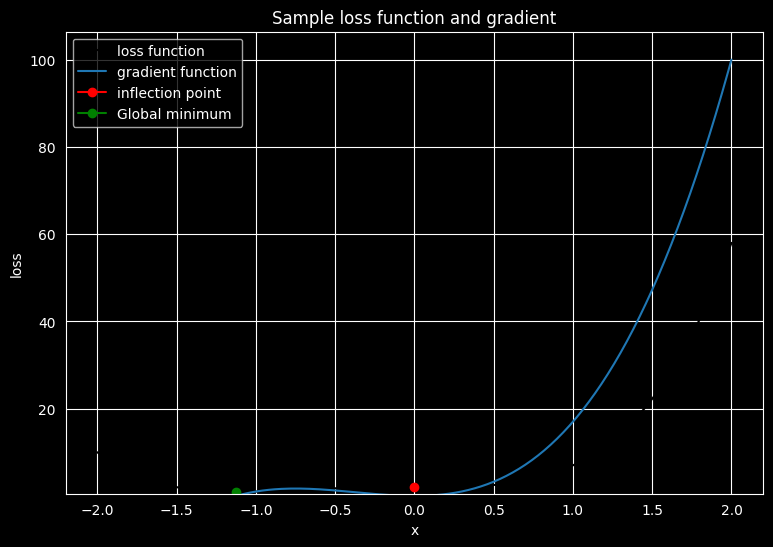

In [10]:
x_vals = tf.linspace(-2, 2, 201)
x_vals = tf.cast(x_vals, tf.float32)

def loss(x):
    return 2 * x ** 4 + 3 * x ** 3 + 2


def grad(f, x):
    with tf.GradientTape() as tape:
        tape.watch(tf.cast(x, dtype=tf.float32))
        result = f(x)
    return tape.gradient(result, x)


plt.plot(x_vals, loss(x_vals), c='k', label='loss function')
plt.plot(x_vals, grad(loss, x_vals), c='tab:blue', label="gradient function")
plt.plot(0, loss(0), marker='o', c='r', label='inflection point')
plt.plot(-9 / 8, loss(-9 / 8), marker='o', c='g', label='Global minimum')
plt.legend()
plt.ylim(0.5)
plt.xlabel('x')
plt.ylabel('loss')
plt.title("Sample loss function and gradient")

In [20]:
def grad(f, x):
    x = tf.cast(x, tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(x)
        result = f(x)
    return tape.gradient(result, x)


def convergence_test(optimizer, loss_fn, grad_fn=grad, init_val=2.0, max_iters=2000, tol=1e-6):
    print(optimizer.title)
    print("---------------------------")
    x_star = tf.Variable(init_val, dtype=tf.float32)
    param_path = []
    converged = False
    for iter in range(1, max_iters + 1):
        x_grad = grad_fn(loss_fn, x_star)
        if x_grad is None:
            raise ValueError("Gradient is None, be sure that x_star is float32 and grad() deives to the same tensor"
                             "that evaluates the loss")
        optimizer.apply_gradients([x_grad], [x_star])
        param_path.append(float(x_star.numpy()))
        if tf.math.abs(x_grad) < tol:
            converged = True
            break
    return {
        "x_star": float(x_star.numpy()),
        "converged": bool(converged),
        "iters": iter,
        "param_path": param_path
    }

In [21]:
param_map_gd = {}
learning_rates = [1e-3, 1e-2, 1e-1, 1.0]
for learning_rate in learning_rates:
    param_map_gd[learning_rate] = GradientDescent(learning_rate=learning_rate)